In [1]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
for pkg in ['albumentations', 'timm', 'segmentation-models-pytorch']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
from glob import glob
from PIL import Image
import cv2
import random
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
  GPU: NVIDIA L4


In [4]:
class CFG:
    # Model paths (update if yours differ)
    EFFNET_PATH = '/content/drive/MyDrive/models/melanomaEfficientNetV2M_lesion1.pth'
    CONVNEXT_PATH = '/content/drive/MyDrive/models/melanomaConvNeXt_lesion1.pth'

    # Image sizes must match what each model was trained on
    EFFNET_IMG_SIZE = 480
    CONVNEXT_IMG_SIZE = 288

    BATCH_SIZE = 16   # conservative for running two models
    TTA_ROUNDS = 9    # match your EfficientNet notebook

    # Ensemble weights (start with equal, then optimize)
    W_EFFNET = 0.5
    W_CONVNEXT = 0.5

    CLASS_NAMES = ['No Melanoma', 'Melanoma']
    SEED = 42


In [5]:
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print(f"Dataset path: {path}")

metadata = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))
image_path_dict = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(path, '*', '*.jpg'))
}
metadata['path'] = metadata['image_id'].map(image_path_dict)
metadata['label'] = (metadata['dx'] == 'mel').astype(int)

# Reproduce the exact same val split
df_unique = metadata.drop_duplicates(subset='lesion_id')
train_df, val_df = train_test_split(
    df_unique, test_size=0.2,
    stratify=df_unique['label'], random_state=SEED
)

print(f"Val set: {len(val_df)} images (Melanoma: {val_df['label'].sum()})")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000
Val set: 1494 images (Melanoma: 123)


In [6]:
def segment_lesion_otsu(image_np):
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    l_channel = lab[:, :, 0]
    blurred = cv2.GaussianBlur(l_channel, (31, 31), 0)
    _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8) * 255
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))
    return (mask > 0).astype(np.float32)


class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row['path']).convert('RGB'))
        label = int(row['label'])
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']
        return image, label


def get_val_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def get_tta_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


# ============================================================
# CELL 5 — Model Definitions (must match training code exactly)
# ============================================================
class SpatialAttentionGate(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 4, 1)
        self.conv2 = nn.Conv2d(in_channels // 4, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        attn = F.gelu(self.conv1(x))
        attn = self.sigmoid(self.conv2(attn))
        return x * attn, attn


class LesionFocusedEfficientNet(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_m.in21k_ft_in1k',
            pretrained=pretrained,
            features_only=False,
            num_classes=0,
            global_pool=''
        )
        feat_dim = self.backbone.num_features
        self.spatial_attn = SpatialAttentionGate(feat_dim)
        self.feature_map = None
        self.norm = nn.LayerNorm(feat_dim)
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward_features(self, x):
        feat = self.backbone.forward_features(x)
        return feat

    def forward(self, x, return_attention=False):
        feat_map = self.forward_features(x)
        attended, attn_map = self.spatial_attn(feat_map)
        pooled = attended.mean(dim=[2, 3])
        pooled = self.norm(pooled)
        logits = self.head(pooled)
        if return_attention:
            return logits, attn_map, feat_map
        return logits


class LesionFocusedConvNeXt(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_base.fb_in1k',
            pretrained=pretrained,
            features_only=False,
            num_classes=0
        )
        feat_dim = self.backbone.num_features
        self.spatial_attn = SpatialAttentionGate(feat_dim)
        self.feature_map = None
        self.backbone.head.global_pool = nn.Identity()
        self.backbone.head.norm = nn.Identity()
        self.norm = nn.LayerNorm(feat_dim)
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward_features(self, x):
        feat = self.backbone.forward_features(x)
        return feat

    def forward(self, x, return_attention=False):
        feat_map = self.forward_features(x)
        attended, attn_map = self.spatial_attn(feat_map)
        pooled = attended.mean(dim=[2, 3])
        pooled = self.norm(pooled)
        logits = self.head(pooled)
        if return_attention:
            return logits, attn_map, feat_map
        return logits


In [7]:
print("Loading EfficientNetV2-M...")
effnet = LesionFocusedEfficientNet(pretrained=False).to(DEVICE)
effnet.load_state_dict(torch.load(CFG.EFFNET_PATH, map_location=DEVICE))
effnet.eval()
print(f"  ✅ Loaded from {CFG.EFFNET_PATH}")

print("Loading ConvNeXt-Base...")
convnext = LesionFocusedConvNeXt(pretrained=False).to(DEVICE)
convnext.load_state_dict(torch.load(CFG.CONVNEXT_PATH, map_location=DEVICE))
convnext.eval()
print(f"  ✅ Loaded from {CFG.CONVNEXT_PATH}")

Loading EfficientNetV2-M...
  ✅ Loaded from /content/drive/MyDrive/models/melanomaEfficientNetV2M_lesion1.pth
Loading ConvNeXt-Base...
  ✅ Loaded from /content/drive/MyDrive/models/melanomaConvNeXt_lesion1.pth


In [8]:
@torch.no_grad()
def get_predictions(model, df, img_size, n_tta=1, batch_size=CFG.BATCH_SIZE):
    """
    Get predicted probabilities from a single model.
    n_tta=1 means plain val transform; n_tta>1 means TTA.
    """
    model.eval()
    all_probs = np.zeros(len(df))
    all_labels = df['label'].values

    for r in range(n_tta):
        if n_tta == 1:
            transform = get_val_transforms(img_size)
        else:
            transform = get_tta_transforms(img_size)

        ds = SkinDataset(df, transform=transform)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
        round_probs = []
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            with autocast():
                logits = model(imgs)
            round_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
        all_probs += np.array(round_probs)

    all_probs /= n_tta
    return all_probs, all_labels


In [9]:
print("Running EfficientNetV2-M with TTA...")
effnet_probs, labels = get_predictions(
    effnet, val_df, CFG.EFFNET_IMG_SIZE, n_tta=CFG.TTA_ROUNDS
)
effnet_auroc = roc_auc_score(labels, effnet_probs)
print(f"  EfficientNetV2-M AUROC: {effnet_auroc:.4f}")

print("\nRunning ConvNeXt-Base with TTA...")
convnext_probs, _ = get_predictions(
    convnext, val_df, CFG.CONVNEXT_IMG_SIZE, n_tta=CFG.TTA_ROUNDS
)
convnext_auroc = roc_auc_score(labels, convnext_probs)
print(f"  ConvNeXt-Base AUROC: {convnext_auroc:.4f}")


Running EfficientNetV2-M with TTA...
  EfficientNetV2-M AUROC: 0.9488

Running ConvNeXt-Base with TTA...
  ConvNeXt-Base AUROC: 0.9410



Grid Search: Optimal Ensemble Weights

🏆 Best ensemble: w_effnet=0.45, w_convnext=0.55
   Ensemble AUROC: 0.9510
   vs EfficientNet alone: 0.9488 (+0.0022)
   vs ConvNeXt alone:     0.9410 (+0.0100)


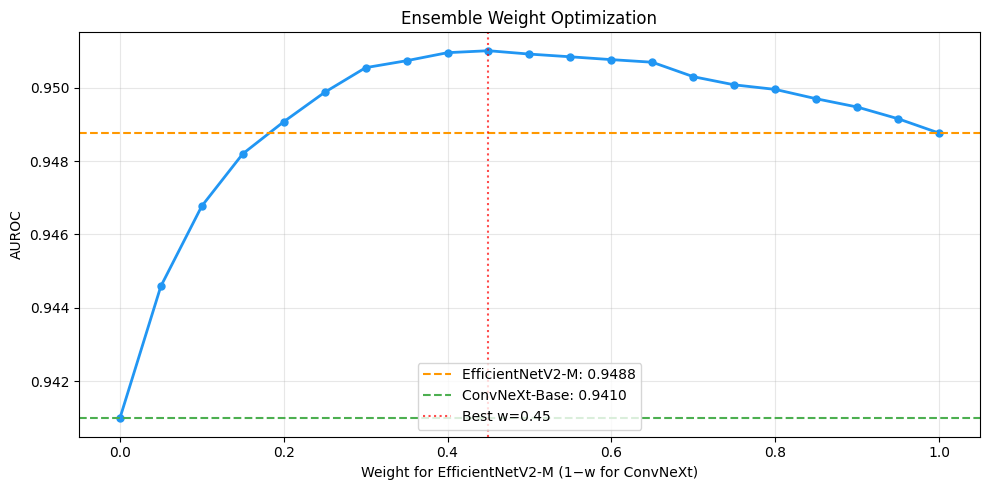

In [10]:
print("\n" + "="*70)
print("Grid Search: Optimal Ensemble Weights")
print("="*70)

best_auroc = 0
best_w = 0.5
results = []

for w in np.arange(0.0, 1.01, 0.05):
    ens_probs = w * effnet_probs + (1 - w) * convnext_probs
    auroc = roc_auc_score(labels, ens_probs)
    results.append((w, auroc))
    if auroc > best_auroc:
        best_auroc = auroc
        best_w = w

print(f"\n🏆 Best ensemble: w_effnet={best_w:.2f}, w_convnext={1-best_w:.2f}")
print(f"   Ensemble AUROC: {best_auroc:.4f}")
print(f"   vs EfficientNet alone: {effnet_auroc:.4f} ({best_auroc - effnet_auroc:+.4f})")
print(f"   vs ConvNeXt alone:     {convnext_auroc:.4f} ({best_auroc - convnext_auroc:+.4f})")

# Update config with optimal weights
CFG.W_EFFNET = best_w
CFG.W_CONVNEXT = 1 - best_w

# Plot weight sweep
fig, ax = plt.subplots(figsize=(10, 5))
ws, aurocs = zip(*results)
ax.plot(ws, aurocs, 'o-', color='#2196F3', linewidth=2, markersize=5)
ax.axhline(effnet_auroc, color='#FF9800', linestyle='--', label=f'EfficientNetV2-M: {effnet_auroc:.4f}')
ax.axhline(convnext_auroc, color='#4CAF50', linestyle='--', label=f'ConvNeXt-Base: {convnext_auroc:.4f}')
ax.axvline(best_w, color='red', linestyle=':', alpha=0.7, label=f'Best w={best_w:.2f}')
ax.set_xlabel('Weight for EfficientNetV2-M (1−w for ConvNeXt)')
ax.set_ylabel('AUROC')
ax.set_title('Ensemble Weight Optimization')
ax.legend(loc='lower center')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Ensemble AUROC: 0.9510
AP (Average Precision): 0.6788

Threshold options:
  Youden's J (balanced) → 0.8405 | Sens 0.886 | FPR 0.112
  FPR ≤ 10% cap         → 0.8553 | Sens 0.846 | FPR 0.098
  F1-optimal            → 0.9220

✅ Using threshold: 0.8405

ENSEMBLE Classification Report (Youden's J threshold)
              precision    recall  f1-score   support

 No Melanoma      0.989     0.888     0.936      1371
    Melanoma      0.416     0.886     0.566       123

    accuracy                          0.888      1494
   macro avg      0.702     0.887     0.751      1494
weighted avg      0.941     0.888     0.905      1494

Matthews Correlation Coefficient (MCC): 0.5599


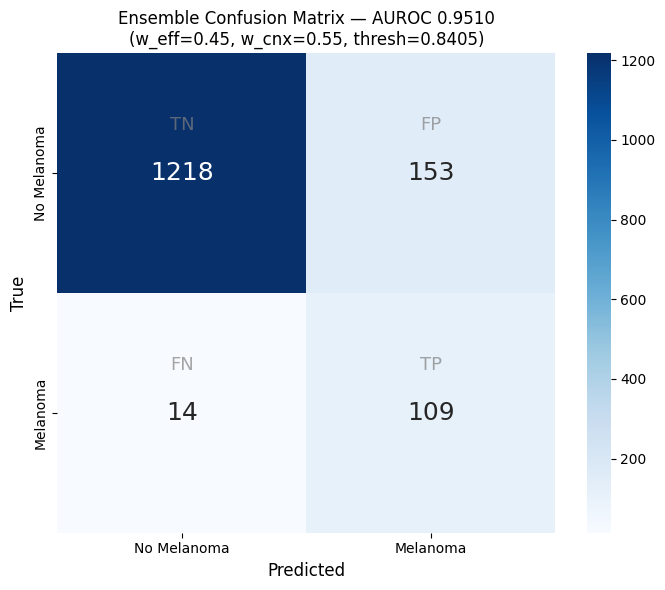

In [11]:
ens_probs = CFG.W_EFFNET * effnet_probs + CFG.W_CONVNEXT * convnext_probs
ens_auroc = roc_auc_score(labels, ens_probs)

fpr, tpr, thresholds = roc_curve(labels, ens_probs)

# Youden's J
j_idx = np.argmax(tpr - fpr)
thresh_youden = thresholds[j_idx]

# FPR ≤ 10%
valid = np.where(fpr <= 0.10)[0]
thresh_fpr10 = thresholds[valid[-1]] if len(valid) else thresh_youden

# F1-optimal
prec_vals, rec_vals, pr_thresholds = precision_recall_curve(labels, ens_probs)
f1_scores = 2 * prec_vals * rec_vals / (prec_vals + rec_vals + 1e-8)
f1_idx = np.argmax(f1_scores)
thresh_f1 = pr_thresholds[f1_idx] if f1_idx < len(pr_thresholds) else 0.5

print(f"\nEnsemble AUROC: {ens_auroc:.4f}")
print(f"AP (Average Precision): {average_precision_score(labels, ens_probs):.4f}")
print("\nThreshold options:")
idx10 = valid[-1] if len(valid) else j_idx
print(f"  Youden's J (balanced) → {thresh_youden:.4f} | Sens {tpr[j_idx]:.3f} | FPR {fpr[j_idx]:.3f}")
print(f"  FPR ≤ 10% cap         → {thresh_fpr10:.4f} | Sens {tpr[idx10]:.3f} | FPR {fpr[idx10]:.3f}")
print(f"  F1-optimal            → {thresh_f1:.4f}")

CHOSEN_THRESH = thresh_youden
print(f"\n✅ Using threshold: {CHOSEN_THRESH:.4f}")


# ============================================================
# CELL 11 — Confusion Matrix & Classification Report
# ============================================================
ens_preds = (ens_probs >= CHOSEN_THRESH).astype(int)

print("\n" + "="*70)
print("ENSEMBLE Classification Report (Youden's J threshold)")
print("="*70)
print(classification_report(labels, ens_preds, target_names=CFG.CLASS_NAMES, digits=3))

mcc = matthews_corrcoef(labels, ens_preds)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# Confusion matrix
cm = confusion_matrix(labels, ens_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.CLASS_NAMES, yticklabels=CFG.CLASS_NAMES,
            annot_kws={'size': 18}, ax=ax)
for (r, c), txt in zip([(0,0),(0,1),(1,0),(1,1)], ['TN','FP','FN','TP']):
    ax.text(c+0.5, r+0.3, txt, ha='center', va='center', fontsize=13, color='gray', alpha=0.7)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Ensemble Confusion Matrix — AUROC {ens_auroc:.4f}\n'
             f'(w_eff={CFG.W_EFFNET:.2f}, w_cnx={CFG.W_CONVNEXT:.2f}, thresh={CHOSEN_THRESH:.4f})',
             fontsize=12)
plt.tight_layout()
plt.show()



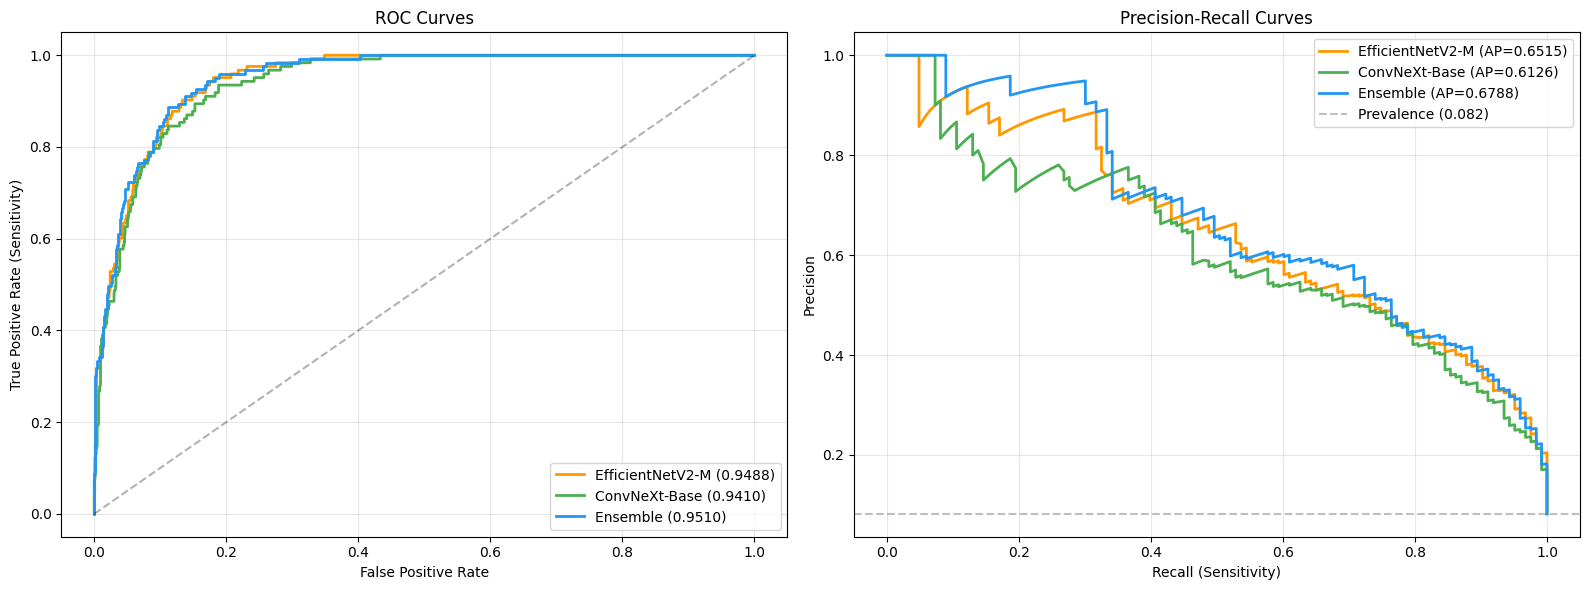

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ROC Curve ---
ax = axes[0]
for name, probs, color in [
    (f'EfficientNetV2-M ({effnet_auroc:.4f})', effnet_probs, '#FF9800'),
    (f'ConvNeXt-Base ({convnext_auroc:.4f})', convnext_probs, '#4CAF50'),
    (f'Ensemble ({ens_auroc:.4f})', ens_probs, '#2196F3'),
]:
    f, t, _ = roc_curve(labels, probs)
    ax.plot(f, t, label=name, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# --- PR Curve ---
ax = axes[1]
for name, probs, color in [
    (f'EfficientNetV2-M (AP={average_precision_score(labels, effnet_probs):.4f})', effnet_probs, '#FF9800'),
    (f'ConvNeXt-Base (AP={average_precision_score(labels, convnext_probs):.4f})', convnext_probs, '#4CAF50'),
    (f'Ensemble (AP={average_precision_score(labels, ens_probs):.4f})', ens_probs, '#2196F3'),
]:
    p, r, _ = precision_recall_curve(labels, probs)
    ax.plot(r, p, label=name, color=color, linewidth=2)

prevalence = labels.mean()
ax.axhline(prevalence, color='gray', linestyle='--', alpha=0.5, label=f'Prevalence ({prevalence:.3f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


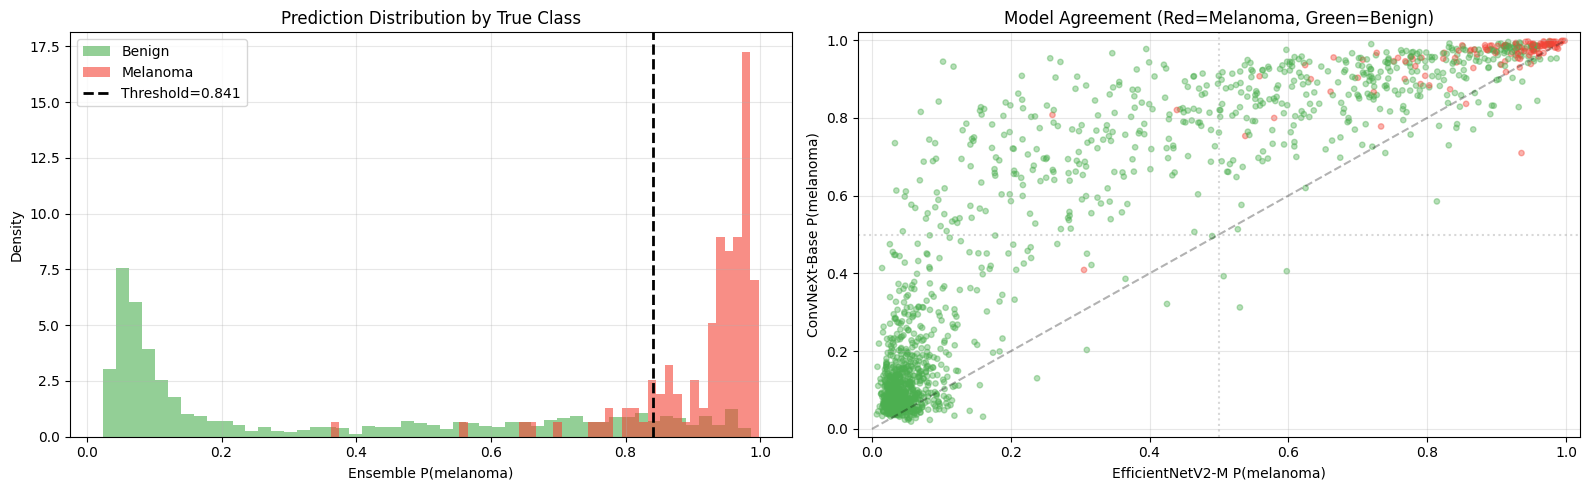

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Probability Distribution ---
ax = axes[0]
mel_mask = labels == 1
ben_mask = labels == 0
ax.hist(ens_probs[ben_mask], bins=50, alpha=0.6, color='#4CAF50', label='Benign', density=True)
ax.hist(ens_probs[mel_mask], bins=50, alpha=0.6, color='#F44336', label='Melanoma', density=True)
ax.axvline(CHOSEN_THRESH, color='black', linestyle='--', linewidth=2, label=f'Threshold={CHOSEN_THRESH:.3f}')
ax.set_xlabel('Ensemble P(melanoma)')
ax.set_ylabel('Density')
ax.set_title('Prediction Distribution by True Class')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Model Agreement Scatter ---
ax = axes[1]
colors = np.where(labels == 1, '#F44336', '#4CAF50')
ax.scatter(effnet_probs, convnext_probs, c=colors, alpha=0.4, s=15)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.3)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('EfficientNetV2-M P(melanoma)')
ax.set_ylabel('ConvNeXt-Base P(melanoma)')
ax.set_title('Model Agreement (Red=Melanoma, Green=Benign)')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*70)
print("Performance at Multiple Thresholds")
print("="*70)
print(f"{'Threshold':>10} {'Sens':>7} {'Spec':>7} {'PPV':>7} {'NPV':>7} {'F1':>7} {'MCC':>7}")
print("-" * 60)

for t in [thresh_youden, thresh_fpr10, thresh_f1, 0.3, 0.5, 0.7, 0.9]:
    preds = (ens_probs >= t).astype(int)
    tp = ((preds == 1) & (labels == 1)).sum()
    tn = ((preds == 0) & (labels == 0)).sum()
    fp = ((preds == 1) & (labels == 0)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    ppv = tp / (tp + fp + 1e-8)
    npv = tn / (tn + fn + 1e-8)
    f1 = 2 * ppv * sens / (ppv + sens + 1e-8)
    m = matthews_corrcoef(labels, preds)
    marker = " ← Youden" if abs(t - thresh_youden) < 1e-6 else ""
    print(f"{t:>10.4f} {sens:>7.3f} {spec:>7.3f} {ppv:>7.3f} {npv:>7.3f} {f1:>7.3f} {m:>7.3f}{marker}")



Performance at Multiple Thresholds
 Threshold    Sens    Spec     PPV     NPV      F1     MCC
------------------------------------------------------------
    0.8405   0.886   0.888   0.416   0.989   0.566   0.560 ← Youden
    0.8553   0.846   0.902   0.437   0.985   0.576   0.562
    0.9220   0.707   0.954   0.580   0.973   0.637   0.605
    0.3000   1.000   0.575   0.174   1.000   0.297   0.316
    0.5000   0.992   0.659   0.207   0.999   0.342   0.366
    0.7000   0.967   0.770   0.274   0.996   0.427   0.447
    0.9000   0.748   0.937   0.514   0.976   0.609   0.579


In [16]:
print("\n" + "="*70)
print("Disagreement Analysis")
print("="*70)

effnet_preds_05 = (effnet_probs >= 0.5).astype(int)
convnext_preds_05 = (convnext_probs >= 0.5).astype(int)

agree = (effnet_preds_05 == convnext_preds_05).sum()
disagree = (effnet_preds_05 != convnext_preds_05).sum()
print(f"Agreement rate: {agree}/{len(labels)} ({agree/len(labels)*100:.1f}%)")
print(f"Disagreements:  {disagree}/{len(labels)} ({disagree/len(labels)*100:.1f}%)")

# Among disagreements, who's right more often?
disagree_mask = effnet_preds_05 != convnext_preds_05
if disagree_mask.sum() > 0:
    effnet_right = (effnet_preds_05[disagree_mask] == labels[disagree_mask]).sum()
    convnext_right = (convnext_preds_05[disagree_mask] == labels[disagree_mask]).sum()
    print(f"\nWhen they disagree:")
    print(f"  EfficientNet correct: {effnet_right}/{disagree_mask.sum()} ({effnet_right/disagree_mask.sum()*100:.1f}%)")
    print(f"  ConvNeXt correct:     {convnext_right}/{disagree_mask.sum()} ({convnext_right/disagree_mask.sum()*100:.1f}%)")

# Correlation between models
from scipy.stats import pearsonr, spearmanr
pearson_r, _ = pearsonr(effnet_probs, convnext_probs)
spearman_r, _ = spearmanr(effnet_probs, convnext_probs)
print(f"\nPrediction correlation:")
print(f"  Pearson r:  {pearson_r:.4f}")
print(f"  Spearman ρ: {spearman_r:.4f}")


# ============================================================
# CELL 16 — Summary Table
# ============================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

summary_data = {
    'Model': ['EfficientNetV2-M', 'ConvNeXt-Base', f'Ensemble (w={CFG.W_EFFNET:.2f}/{CFG.W_CONVNEXT:.2f})'],
    'AUROC': [effnet_auroc, convnext_auroc, ens_auroc],
    'AP': [
        average_precision_score(labels, effnet_probs),
        average_precision_score(labels, convnext_probs),
        average_precision_score(labels, ens_probs),
    ],
}

# Compute sens/spec at Youden threshold for each
for name, probs in [('EfficientNetV2-M', effnet_probs), ('ConvNeXt-Base', convnext_probs), ('Ensemble', ens_probs)]:
    f, t, th = roc_curve(labels, probs)
    j = np.argmax(t - f)
    if name not in summary_data:
        pass  # just computing for table below

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, float_format='%.4f'))

print(f"\n✅ Ensemble achieves AUROC {ens_auroc:.4f}")
print(f"   Improvement over best single model: {ens_auroc - max(effnet_auroc, convnext_auroc):+.4f}")


Disagreement Analysis
Agreement rate: 1273/1494 (85.2%)
Disagreements:  221/1494 (14.8%)

When they disagree:
  EfficientNet correct: 216/221 (97.7%)
  ConvNeXt correct:     5/221 (2.3%)

Prediction correlation:
  Pearson r:  0.8999
  Spearman ρ: 0.8648

FINAL SUMMARY
                 Model  AUROC     AP
      EfficientNetV2-M 0.9488 0.6515
         ConvNeXt-Base 0.9410 0.6126
Ensemble (w=0.45/0.55) 0.9510 0.6788

✅ Ensemble achieves AUROC 0.9510
   Improvement over best single model: +0.0022
